# Selección de sensores del distrito de Chamberí

> Cuaderno 2 de 5 del TFM

 Parte del distrito obtenido en el cuaderno *Selección distrito* (Chamberí, distrito 7) y genera la batería de doce sensores que utiliza el cuaderno de preprocesamiento.

Periodo de análisis: 2023–2025 (36 meses). A diferencia de la selección del distrito, que se realiza con cuatro meses de 2025, la selección de sensores exige los tres años completos: un sensor con buena cobertura en 2025 pero con huecos en 2023 o 2024 introduciría series incompletas en el conjunto de entrenamiento del modelo.

| Sección | Contenido | Resultado |
|---|---|---|
| 0 | Configuración y parámetros | — |
| 1 | Estabilidad de los puntos de medida | De 142 se seleccionan 141 sensores |
| 2 | Disponibilidad de datos en el histórico | De 141 se seleccionan 134 sensores |
| 3 | Perfil horario laborable | Confirmación de la franja punta 7:00–9:45 h |
| 4 | Indicadores DCL, ICPM y completitud | Tabla de indicadores por sensor |
| 5 | Clasificación y caracterización por tipología viaria | Cuatro tipologías |
| 6 | Selección de la batería de sensores | De 134 por completitud se seleccionan 94 aptos de los que finalmente se seleccionan 12  |
| 7 | Apéndice. Selección sensores sin cuotas por tipología | - |

## 0. Configuración

### Librerías

In [1]:
import calendar
import re
import unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import glob
import geopandas as gpd
from matplotlib.patheffects import withStroke
from shapely.geometry import Point
from docx import Document

### Parámetros

In [2]:
BASE_DIR       = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\dataset')
CARPETA_SALIDA = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\resultados\sensores')
CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)

SEPARADOR     = ';'
CODIFICACION  = 'latin-1'
FORMATO_FECHA = '%Y-%m-%d %H:%M:%S'
TAM_BLOQUE    = 2_000_000         

DISTRITO_OBJ  = 7                  
TIPO_ELEM_OBJ = 'URB'              
AÑOS          = [2023, 2024, 2025]
MES_REFERENCIA_PTOS = '202512'    
FREQ_REG_HORA = 4                  

HORA_PUNTA_INICIO = 7
HORA_PUNTA_FIN    = 9
HORAS_PUNTA = set(range(HORA_PUNTA_INICIO, HORA_PUNTA_FIN + 1))

COMPLETITUD_MIN = 0.98
CUOTAS = {'Arterial': 3, 'Principal': 3, 'Secundaria': 3, 'Residencial': 3}
PESOS_ESTABILIDAD = np.round(np.arange(0.20, 0.80 + 1e-9, 0.05), 2)   

ORDEN_TIP = ['Arterial', 'Principal', 'Secundaria', 'Residencial']
COLORES_TIP = {'Arterial': '#d62728', 'Principal': '#ff7f0e',
               'Secundaria': '#2ca02c', 'Residencial': '#1f77b4'}

## 1. Estabilidad de los puntos de medida

Se comprueba en qué meses del periodo 2023–2025 aparece cada sensor urbano de Chamberí en el fichero de puntos de medida. Solo se consideran los sensores presentes en los 36 meses.

In [3]:
FICHEROS_PTOS = {f'{a}{m:02d}': BASE_DIR / 'ptos_medida' / f'{a}{m:02d}.csv'
                 for a in AÑOS for m in range(1, 13)}
N_MESES = len(FICHEROS_PTOS)

def leer_ptos_medida(ruta: Path) -> pd.DataFrame:
    df = pd.read_csv(ruta, sep=SEPARADOR, encoding=CODIFICACION)
    df.columns = [c.strip().strip('"') for c in df.columns]
    df['id'] = df['id'].astype(str).str.strip()
    df['distrito'] = pd.to_numeric(df['distrito'], errors='coerce')
    df = df.dropna(subset=['distrito'])
    df['distrito'] = df['distrito'].astype(int)
    for col in ['longitud', 'latitud']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
    es_urbano = df['tipo_elem'].astype(str).str.strip().str.upper() == TIPO_ELEM_OBJ
    return df[es_urbano & (df['distrito'] == DISTRITO_OBJ)].copy()

ptos_por_mes = {mes: leer_ptos_medida(ruta) for mes, ruta in FICHEROS_PTOS.items()}

ids_todos = sorted(set().union(*(set(d['id']) for d in ptos_por_mes.values())))
serie_ids = pd.Series(ids_todos, index=ids_todos)
presencia = pd.DataFrame({mes: serie_ids.isin(d['id']).astype(int) for mes, d in ptos_por_mes.items()})
presencia['n_meses'] = presencia.sum(axis=1)

sensores_estables   = presencia.index[presencia['n_meses'] == N_MESES].tolist()
sensores_inestables = presencia.index[presencia['n_meses'] <  N_MESES].tolist()

print(f'Sensores urbanos registrados en el distrito: {len(ids_todos)}')
print(f'Presentes en los {N_MESES} meses:            {len(sensores_estables)}')
print(f'Con ausencias en algún mes:                {len(sensores_inestables)}')
for sid in sensores_inestables:
    ausentes = [m for m in FICHEROS_PTOS if presencia.loc[sid, m] == 0]
    print(f'  Sensor {sid}: ausente en {len(ausentes)} meses ({ausentes[0]} – {ausentes[-1]})')

resumen_estabilidad = (presencia.rename_axis('id').reset_index().groupby('n_meses')['id']
                       .agg(n_sensores='count', ids=lambda x: ', '.join(map(str, x)))
                       .sort_index(ascending=False).reset_index())
resumen_estabilidad.to_csv(CARPETA_SALIDA / 'resumen_estabilidad_sensores.csv',
                           sep=SEPARADOR, index=False, encoding=CODIFICACION)

Sensores urbanos registrados en el distrito: 142
Presentes en los 36 meses:            141
Con ausencias en algún mes:                1
  Sensor 7081: ausente en 25 meses (202311 – 202512)


El único sensor que no aparece en todos los meses es el **7081**, presente solo en los once primeros meses de 2023, por lo que se descarta. Quedan 141 sensores estables.

## 2. Disponibilidad de datos en el histórico

La presencia de un sensor en el fichero de puntos de medida no garantiza que tenga registros de tráfico. Se lee el histórico de los 141 sensores estables y se agrega por sensor, tipo de día y hora, acumulando la suma de carga y el número de mediciones de los 36 meses.

### Lectura y agregación del histórico

In [4]:
FICHEROS_HISTORICO = {f'{m:02d}{a}': BASE_DIR / 'historico' / f'{m:02d}{a}.zip'
                      for a in AÑOS for m in range(1, 13)}
COLUMNAS_HIST = ['id', 'fecha', 'carga']

acumulado, meses_leidos = [], 0
for nombre, ruta in FICHEROS_HISTORICO.items():
    filas_mes = 0
    for bloque in pd.read_csv(ruta, sep=SEPARADOR, usecols=COLUMNAS_HIST, chunksize=TAM_BLOQUE,
                              encoding=CODIFICACION, compression='zip'):
        bloque['id'] = bloque['id'].astype(str).str.strip()
        bloque = bloque[bloque['id'].isin(sensores_estables)].copy()
        if bloque.empty:
            continue
        bloque['carga'] = pd.to_numeric(bloque['carga'], errors='coerce')
        bloque = bloque[bloque['carga'] >= 0]
        bloque['fecha'] = pd.to_datetime(bloque['fecha'], format=FORMATO_FECHA, errors='coerce')
        bloque = bloque.dropna(subset=['fecha'])
        bloque['hora'] = bloque['fecha'].dt.hour
        bloque['es_laborable'] = bloque['fecha'].dt.dayofweek < 5     # lunes a viernes
        acumulado.append(bloque.groupby(['id', 'es_laborable', 'hora'])['carga']
                               .agg(carga='sum', mediciones='count').reset_index())
        filas_mes += len(bloque)
    print(f'  {nombre}: {filas_mes:>9,} registros')
    meses_leidos += 1

# df_hist: una fila por sensor, tipo de día y hora
df_hist = (pd.concat(acumulado, ignore_index=True)
             .groupby(['id', 'es_laborable', 'hora'], as_index=False)[['carga', 'mediciones']].sum())
df_hist['carga_media'] = df_hist['carga'] / df_hist['mediciones']

print(f'\nMeses leídos: {meses_leidos}/{len(FICHEROS_HISTORICO)}')

  012023:   393,277 registros
  022023:   352,718 registros
  032023:   389,562 registros
  042023:   379,290 registros
  052023:   393,743 registros
  062023:   381,994 registros
  072023:   393,674 registros
  082023:   389,814 registros
  092023:   379,782 registros
  102023:   392,328 registros
  112023:   381,419 registros
  122023:   391,451 registros
  012024:   392,401 registros
  022024:   367,470 registros
  032024:   393,636 registros
  042024:   380,848 registros
  052024:   390,173 registros
  062024:   380,067 registros
  072024:   385,300 registros
  082024:   371,789 registros
  092024:   374,689 registros
  102024:   390,726 registros
  112024:   372,517 registros
  122024:   391,470 registros
  012025:   387,994 registros
  022025:   346,891 registros
  032025:   389,717 registros
  042025:   352,554 registros
  052025:   389,025 registros
  062025:   376,583 registros
  072025:   391,147 registros
  082025:   384,535 registros
  092025:   379,270 registros
  102025: 

### Sensores con y sin registros

In [5]:
sensores_con_datos = set(df_hist['id'].unique())
sensores_sin_datos = set(sensores_estables) - sensores_con_datos

print(f'Sensores estables:                 {len(sensores_estables)}')
print(f'Con registros en el histórico:     {len(sensores_con_datos)}')
print(f'Sin ningún registro:               {len(sensores_sin_datos)} : {sorted(sensores_sin_datos)}')

Sensores estables:                 141
Con registros en el histórico:     134
Sin ningún registro:               7 : ['10560', '4397', '4465', '4466', '4467', '4468', '4469']


Siete sensores (4397, 4465, 4466, 4467, 4468, 4469 y 10560) no tienen ningún registro en el periodo y se excluyen. El conjunto de partida para la selección queda en 134 sensores estables y con datos.

## 3. Perfil horario laborable y franja punta

Antes de definir los criterios de selección se comprueba, sobre los 134 sensores y los tres años completos, el patrón horario observado en el análisis de distritos (cuatro meses de 2025): el aumento de la carga en días laborables se concentra entre las 7:00 y las 9:45 h.

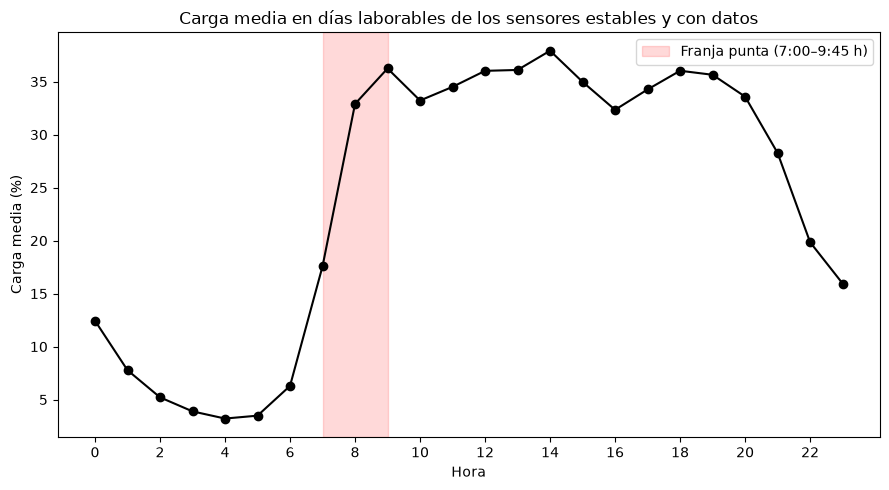

In [6]:
lab = df_hist[df_hist['es_laborable']]
perfil_medio_lab = lab.groupby('hora')['carga'].sum() / lab.groupby('hora')['mediciones'].sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(perfil_medio_lab.index, perfil_medio_lab.values, marker='o', color='black')
ax.axvspan(HORA_PUNTA_INICIO, HORA_PUNTA_FIN, alpha=0.15, color='red', label='Franja punta (7:00–9:45 h)')
ax.set_xlabel('Hora')
ax.set_ylabel('Carga media (%)')
ax.set_xticks(range(0, 24, 2))
ax.set_title('Carga media en días laborables de los sensores estables y con datos')
ax.legend()
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'hora_punta_sensores_estables_condatos.png', dpi=150)
plt.show()

## 4. Definición de indicadores por sensor

Se calculan tres indicadores para cada uno de los 134 sensores. Todas las medias de carga están ponderadas por el número de mediciones de cada hora.

* **DCL (Diferencial de Carga Laborable):** diferencia entre la carga media registrada durante la franja punta de los días laborables y la correspondiente a los días no laborables. Este indicador permite caracterizar el incremento de carga asociado al calendario laboral.

  $$
  DCL = \bar{C}^{\,lab}_{punta} - \bar{C}^{\,no\,lab}_{punta}
  $$

* **ICPM (Índice de Concentración del Pico Matutino):** relación entre la carga media registrada durante la franja punta de los días laborables y la carga media del conjunto del día laborable. Este indicador permite cuantificar la concentración de la carga viaria en la franja punta.

  $$
  ICPM = \frac{\bar{C}^{\,lab}_{punta}}{\bar{C}^{\,lab}_{día}}
  $$

* **Completitud:** proporción de mediciones registradas respecto al número de mediciones esperadas para el periodo analizado. Se utiliza como indicador de la calidad y continuidad de la serie temporal, estableciéndose como criterio de aceptación una completitud mínima de 0,98, equivalente a permitir como máximo aproximadamente un mes sin datos en un periodo de tres años.

  $$
  \text{Completitud} =
  \frac{\text{mediciones registradas}}
  {\text{mediciones esperadas}}
  $$


In [7]:
MEDICIONES_ESPERADAS = sum(366 if calendar.isleap(a) else 365 for a in AÑOS) * 24 * FREQ_REG_HORA

def media_ponderada(sub: pd.DataFrame) -> float:
    if sub.empty or sub['mediciones'].sum() == 0:
        return np.nan
    return np.average(sub['carga_media'], weights=sub['mediciones'])

def carga_pond(datos, laborable, solo_punta):
    sub = datos[datos['es_laborable'] == laborable]
    if solo_punta:
        sub = sub[sub['hora'].isin(HORAS_PUNTA)]
    return media_ponderada(sub)


def dcl(datos):
    lab, nolab = carga_pond(datos, True, True), carga_pond(datos, False, True)
    return round(lab - nolab, 2) if pd.notna(lab) and pd.notna(nolab) else np.nan


def icpm(datos):
    dia, punta = carga_pond(datos, True, False), carga_pond(datos, True, True)
    if pd.isna(dia) or dia == 0 or pd.isna(punta):
        return np.nan
    return round(punta / dia, 4)


def completitud(datos):
    return min(round(datos['mediciones'].sum() / MEDICIONES_ESPERADAS, 3), 1.0)


filas = []
for sid, datos in df_hist.groupby('id'):
    filas.append({
        'id':                sid,
        'carga_punta_lab':   carga_pond(datos, True, True),
        'carga_punta_nolab': carga_pond(datos, False, True),
        'carga_dia_lab':     carga_pond(datos, True, False),
        'DCL':               dcl(datos),
        'ICPM':              icpm(datos),
        'Completitud':       completitud(datos),
        'med_total':         int(datos['mediciones'].sum())})
df_indicadores = pd.DataFrame(filas)

print(f'Mediciones esperadas por sensor (2023–2025): {MEDICIONES_ESPERADAS:,}')
print(f'Sensores con indicadores calculados: {len(df_indicadores)}')
df_indicadores.describe().round(3)

Mediciones esperadas por sensor (2023–2025): 105,216
Sensores con indicadores calculados: 134


,carga_punta_lab,carga_punta_nolab,carga_dia_lab,DCL,ICPM,Completitud,med_total
count,134.000,134.000,134.000,134.000,134.000,134.000,134.000
mean,28.906,8.804,24.109,20.102,1.200,0.976,102642.836
std,10.934,3.983,8.605,8.340,0.219,0.051,5335.152
min,2.595,2.110,3.466,0.480,0.748,0.480,50458.000
25%,21.908,6.044,18.960,14.772,1.037,0.972,102325.250
50%,27.309,7.958,23.936,18.560,1.160,0.991,104247.500
75%,35.999,10.537,28.133,24.635,1.347,0.994,104596.500
max,67.665,21.958,55.533,45.710,1.742,0.996,104796.000


## 5. Clasificación por tipología viaria

Cada sensor se asigna a una de cuatro tipologías (arterial, principal, secundaria o residencial) según la función de la vía en la que se ubica, siguiendo la jerarquía de la Instrucción de Vía Pública del Ayuntamiento de Madrid. La asignación se hace por coincidencia de palabras clave sobre el nombre normalizado de la vía; se comparan primero las claves más largas para evitar coincidencias parciales.

Para los nombres de vía y las coordenadas se utiliza el fichero de puntos de medida de diciembre de 2025, que contiene los 141 sensores estables.

In [8]:
def quita_tildes(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')


def via_principal(nombre: str) -> str:
    # Normaliza el nombre del punto de medida y devuelve solo la vía en la que se ubica.
    n = str(nombre).lower()
    n = re.sub(r'\(aforos?\)|\(micro\)|\(tactico\)', '', n)
    n = n.split('(')[0].split(',')[0]
    n = re.sub(r'\b[oens]-[oens]\b', '', n)      # sentido de circulación (O-E, S-N...)
    n = n.split(' - ')[0]
    n = quita_tildes(n)
    n = re.sub(r'\bsta\.?', 'santa ', n)
    n = n.replace('pº', 'paseo ')
    n = re.sub(r'\bav\.?\b', 'avenida', n)
    n = re.sub(r'\bgral\.?', 'general ', n)
    n = re.sub(r'\bfdez\.?', 'fernandez ', n)
    n = re.sub(r'[.\d]', '', n)
    n = re.sub(r'\s+', ' ', n).strip(' -')
    return n

df_id = leer_ptos_medida(BASE_DIR / 'ptos_medida' / f'{MES_REFERENCIA_PTOS}.csv')
df_id = df_id[df_id['id'].isin(sensores_con_datos)].copy()
df_id['via_principal'] = df_id['nombre'].apply(via_principal)

assert len(df_id) == len(sensores_con_datos), 'Hay sensores con datos que no figuran en el fichero de referencia'
print(f'Sensores candidatos en el catálogo: {len(df_id)}')

Sensores candidatos en el catálogo: 134


### Diccionario de vias

In [9]:
CLASIF = {
    'Arterial': [
        'paseo castellana', 'castellana', 'bravo murillo', 'reina victoria',
        'moncloa', 'fernandez de los rios', 'juan xxiii', 'pablo iglesias'],
    'Principal': [
        'santa engracia', 'jose abascal', 'raimundo fernandez villaverde',
        'alberto aguilera', 'genova', 'sagasta', 'eduardo dato', 'rios rosas',
        'cea bermudez', 'carranza', 'fuencarral', 'fuencarra', 'princesa'],
    'Secundaria': [
        'almagro', 'zurbano', 'modesto lafuente', 'fortuny', 'miguel angel',
        'isaac peral', 'vallehermoso', 'guzman el bueno', 'donoso cortes',
        'agustin de bethancourt', 'agustin de betancourt', 'alonso cano',
        'general martinez campos', 'general ibanez ibero', 'garcia paredes', 'filipinas'],
    'Residencial': [
        'san francisco de sales', 'san francisco sales', 'san fco de sales', 'andres mellado',
        'melendez valdes', 'blasco de garay', 'eloy gonzalo', 'fernando el catolico',
        'rodriguez san pedro', 'san bernardo', 'alburquerque', 'luchana',
        'francisco de rojas', 'san juan de la cruz', 'avenida del valle', 'del valle',
        'santander', 'gonzalo de cordoba', 'salida'],
}
TIPOLOGIA_DEFAULT = 'Residencial'

# Variantes de nombre de una misma vía
ALIAS_VIA = {
    'paseo castellana': 'castellana', 'san francisco sales': 'san francisco de sales',
    'san fco de sales': 'san francisco de sales', 'del valle': 'avenida del valle',
    'fuencarra': 'fuencarral', 'agustin de betancourt': 'agustin de bethancourt'}

### Clasificación de los sensores

In [10]:
def clasificar(nombre: str, diccionario: dict):
    # Devuelve (tipología, clave de vía, asignada_por_defecto)
    v = via_principal(nombre)
    claves = sorted([(c, t) for t, cs in diccionario.items() for c in cs], key=lambda x: -len(x[0]))
    for clave, tipo in claves:
        if clave in v:
            return tipo, ALIAS_VIA.get(clave, clave), False
    return TIPOLOGIA_DEFAULT, v, True


df_id[['tipologia', 'via_clave', 'por_defecto']] = df_id['nombre'].apply(lambda n: pd.Series(clasificar(n, CLASIF)))

# Comprobaciones
vias_ambiguas = df_id.groupby('via_clave')['tipologia'].nunique().loc[lambda s: s > 1]
print(f'Vías asignadas a más de una tipología: {len(vias_ambiguas)}')
sin_asignar = df_id[df_id['por_defecto']]
print(f'Sensores sin vía en el diccionario (tipología por defecto): {len(sin_asignar)}')
if not sin_asignar.empty:
    print(sin_asignar[['id', 'nombre', 'via_principal']].to_string(index=False))

print('\nSensores por tipología:')
print(df_id['tipologia'].value_counts().reindex(ORDEN_TIP).to_string())
cols_via = ['nombre', 'via_principal', 'via_clave', 'tipologia', 'por_defecto']

# Se incorporan nombre de vía y tipologías a la tabla de indicadores
df_indicadores = (df_indicadores
                  .drop(columns=[c for c in df_indicadores.columns
                                 if c.split('_x')[0].split('_y')[0] in cols_via + ['nombre_via']],
                        errors='ignore')
                  .merge(df_id[['id'] + cols_via].rename(columns={'nombre': 'nombre_via'}),
                         on='id', how='left'))

Vías asignadas a más de una tipología: 0
Sensores sin vía en el diccionario (tipología por defecto): 0

Sensores por tipología:
tipologia
Arterial       20
Principal      41
Secundaria     39
Residencial    34


In [11]:
NOMBRE_OFICIAL = {
    'castellana': 'Paseo de la Castellana', 'bravo murillo': 'Calle de Bravo Murillo',
    'reina victoria': 'Avenida de la Reina Victoria', 'fernandez de los rios': 'Calle de Fernández de los Ríos',
    'moncloa': 'Avenida de la Moncloa', 'pablo iglesias': 'Avenida de Pablo Iglesias', 'juan xxiii': 'Paseo de Juan XXIII',
    'alberto aguilera': 'Calle de Alberto Aguilera', 'raimundo fernandez villaverde': 'Calle de Raimundo Fernández Villaverde',
    'cea bermudez': 'Calle de Cea Bermúdez', 'eduardo dato': 'Paseo de Eduardo Dato', 'santa engracia': 'Calle de Santa Engracia',
    'jose abascal': 'Calle de José Abascal', 'rios rosas': 'Calle de Ríos Rosas', 'fuencarral': 'Calle de Fuencarral',
    'princesa': 'Calle de la Princesa', 'carranza': 'Calle de Carranza', 'genova': 'Calle de Génova', 'sagasta': 'Calle de Sagasta',
    'general martinez campos': 'Paseo del General Martínez Campos', 'guzman el bueno': 'Calle de Guzmán el Bueno',
    'vallehermoso': 'Calle de Vallehermoso', 'filipinas': 'Avenida de Filipinas', 'agustin de bethancourt': 'Calle de Agustín de Betancourt',
    'miguel angel': 'Calle de Miguel Ángel', 'almagro': 'Calle de Almagro', 'isaac peral': 'Calle de Isaac Peral',
    'modesto lafuente': 'Calle de Modesto Lafuente', 'alonso cano': 'Calle de Alonso Cano', 'donoso cortes': 'Calle de Donoso Cortés',
    'garcia paredes': 'Calle de García de Paredes', 'general ibanez ibero': 'Calle del General Ibáñez de Ibero',
    'zurbano': 'Calle de Zurbano', 'fortuny': 'Calle de Fortuny',
    'san francisco de sales': 'Paseo de San Francisco de Sales', 'fernando el catolico': 'Calle de Fernando el Católico',
    'eloy gonzalo': 'Calle de Eloy Gonzalo', 'blasco de garay': 'Calle de Blasco de Garay', 'luchana': 'Calle de Luchana',
    'melendez valdes': 'Calle de Meléndez Valdés', 'rodriguez san pedro': 'Calle de Rodríguez San Pedro',
    'san bernardo': 'Calle de San Bernardo', 'alburquerque': 'Calle de Alburquerque', 'andres mellado': 'Calle de Andrés Mellado',
    'avenida del valle': 'Avenida del Valle', 'francisco de rojas': 'Calle de Francisco de Rojas',
    'gonzalo de cordoba': 'Calle de Gonzalo de Córdoba', 'san juan de la cruz': 'Plaza de San Juan de la Cruz',
    'santander': 'Calle de Santander', 'salida': 'Salidas del complejo de Nuevos Ministerios'}

anexo_vias = (df_id.groupby('via_clave')
                   .agg(tipologia=('tipologia', 'first'),sensores=('id', lambda s: ', '.join(sorted(s, key=int))),n_sensores=('id', 'count'))
                   .reset_index())
anexo_vias['via'] = anexo_vias['via_clave'].map(NOMBRE_OFICIAL)
sin_nombre = anexo_vias.loc[anexo_vias['via'].isna(), 'via_clave'].tolist()
if sin_nombre:
    print(f'Vías sin nombre oficial en NOMBRE_OFICIAL: {sin_nombre}')
    anexo_vias['via'] = anexo_vias['via'].fillna(anexo_vias['via_clave'].str.title())

anexo_vias['tipologia'] = pd.Categorical(anexo_vias['tipologia'], ORDEN_TIP, ordered=True)
anexo_vias = (anexo_vias.sort_values(['tipologia', 'n_sensores', 'via'], ascending=[True, False, True])
                        [['tipologia', 'via', 'sensores', 'n_sensores']].reset_index(drop=True))

# Resumen por tipología
print(anexo_vias.groupby('tipologia', observed=True).agg(n_vias=('via', 'count'), n_sensores=('n_sensores', 'sum')))
anexo_vias.to_csv(CARPETA_SALIDA / 'anexo_vias_tipologias.csv', index=False, sep=';', encoding='utf-8-sig')

# Exportación a Word 
doc = Document()
tabla = doc.add_table(rows=1, cols=4)
for c, h in zip(tabla.rows[0].cells, ['Tipología', 'Vía', 'Sensores (id)', 'N.º']):
    c.text = h
anterior = None
for _, r in anexo_vias.iterrows():
    celdas = tabla.add_row().cells
    celdas[0].text = str(r['tipologia']) if r['tipologia'] != anterior else ''
    anterior = r['tipologia']
    celdas[1].text, celdas[2].text, celdas[3].text = r['via'], r['sensores'], str(r['n_sensores'])
doc.save(CARPETA_SALIDA / 'anexo_vias_tipologias.docx')
print('Tabla guardada en anexo_vias_tipologias.docx')

anexo_vias

             n_vias  n_sensores
tipologia                      
Arterial          7          20
Principal        12          41
Secundaria       13          39
Residencial      16          34
Tabla guardada en anexo_vias_tipologias.docx


,tipologia,via,sensores,n_sensores
0,Arterial,Paseo de la Castellana,"3562, 3851, 4436, 4461, 4462, 5457",6
1,Arterial,Avenida de la Reina Victoria,"5710, 5775, 5776, 5777",4
2,Arterial,Calle de Bravo Murillo,"3693, 4404, 4409, 4454",4
3,Arterial,Calle de Fernández de los Ríos,"4381, 4403, 10603",3
4,Arterial,Avenida de Pablo Iglesias,3411,1
5,Arterial,Avenida de la Moncloa,5774,1
6,Arterial,Paseo de Juan XXIII,3499,1
7,Principal,Calle de Alberto Aguilera,"4383, 4384, 4388, 5130, 7067, 10217",6
8,Principal,Calle de Raimundo Fernández Villaverde,"5472, 5711, 5712, 5713, 5714, 5739",6
9,Principal,Calle de Cea Bermúdez,"3396, 3397, 4419, 4421, 9977",5


### Caracterización de los valores medios por tipología

In [12]:
def caracterizar_tipologias(indicadores: pd.DataFrame, col_tip: str = 'tipologia', titulo: str = '') -> pd.DataFrame:
    tabla = (indicadores.groupby(col_tip)
                        .agg(n_sensores=('id', 'count'),
                             carga_punta_lab=('carga_punta_lab', 'mean'),
                             carga_punta_nolab=('carga_punta_nolab', 'mean'),
                             carga_dia_lab=('carga_dia_lab', 'mean'),
                             DCL_media=('DCL', 'mean'),
                             ICPM_medio=('ICPM', 'mean'))
                        .reindex(ORDEN_TIP).round(2))
    tabla.index.name = 'tipologia'
    if titulo:
        print(titulo)
    return tabla


tabla_tipologias_134 = caracterizar_tipologias(df_indicadores, titulo='Caracterización de los 134 sensores del distrito')
tabla_tipologias_134.to_csv(CARPETA_SALIDA / 'caracterizacion_tipologias_134.csv')
tabla_tipologias_134

Caracterización de los 134 sensores del distrito


,n_sensores,carga_punta_lab,carga_punta_nolab,carga_dia_lab,DCL_media,ICPM_medio
tipologia,,,,,,
Arterial,20,28.84,7.52,22.69,21.32,1.28
Principal,41,34.20,10.68,28.61,23.52,1.20
Secundaria,39,28.00,8.32,23.83,19.69,1.19
Residencial,34,23.59,7.86,19.84,15.74,1.16


### Dispersión dentro de cada tipología

Detalle por sensor y desviación típica de cada grupo, para valorar la coherencia interna de la clasificación (dispersión dentro de cada tipología frente a diferencias entre tipologías).

In [13]:
for tipo in ORDEN_TIP:
    sub = df_indicadores[df_indicadores['tipologia'] == tipo].sort_values('carga_punta_lab', ascending=False)
    if sub.empty:
        continue
    print(f"\n{'=' * 70}\n{tipo}  (n={len(sub)})\n{'=' * 70}")
    print(sub[['id', 'via_clave', 'carga_punta_lab', 'DCL', 'ICPM']].round(2).to_string(index=False))

dispersion_tipologias = (df_indicadores.groupby('tipologia')
                         .agg(n=('id', 'count'),
                              carga_media=('carga_punta_lab', 'mean'), carga_std=('carga_punta_lab', 'std'),
                              DCL_media=('DCL', 'mean'), DCL_std=('DCL', 'std'),
                              ICPM_medio=('ICPM', 'mean'), ICPM_std=('ICPM', 'std'))
                         .reindex(ORDEN_TIP).round(2))
print(f"\n{'=' * 70}\nRESUMEN POR TIPOLOGÍA (media y desviación típica)")
print(dispersion_tipologias.to_string())


Arterial  (n=20)
   id             via_clave  carga_punta_lab   DCL  ICPM
 5775        reina victoria            39.79 34.66  1.72
 5777        reina victoria            39.49 33.81  1.60
 5774               moncloa            39.12 33.51  1.74
 5776        reina victoria            37.29 31.55  1.48
 4403 fernandez de los rios            32.11 22.02  1.32
 4461            castellana            31.94 23.43  1.16
 3411        pablo iglesias            31.76 23.34  1.24
 4462            castellana            31.15 22.66  1.14
 4454         bravo murillo            28.35 16.04  1.11
10603 fernandez de los rios            28.28 20.66  1.45
 3562            castellana            27.83 19.66  1.10
 3693         bravo murillo            27.24 17.14  1.09
 4381 fernandez de los rios            26.84 17.31  1.35
 4409         bravo murillo            26.17 18.26  1.06
 5710        reina victoria            25.66 19.12  1.40
 3851            castellana            25.61 16.50  0.95
 5457        

### Mapa representación tipologías

Sensores cuya vía no se encuentra en el grafo de carriles: 7
   id                                                                                                              nombre          via_clave   tipologia
 7082 (TACTICO)Salida Edificio Nuevos Ministerios(Delante G.4) - (TACTICO)Salida Edificio Nuevos Ministerios(Delante G.4)             salida Residencial
10499                                                          Andrés Mellado S-N(Meléndez Valdés - Fernando el Católico)     andres mellado Residencial
 4416                                                               Gonzalo de Córdoba E-O - Cardenal Cisneros-Fuencarral gonzalo de cordoba Residencial
 4375                                                                      DONOSO CORTES E-O(HILARION ESLAVA-ISAAC PERAL)      donoso cortes  Secundaria
 9967                                                                                        (TACTICO) SALIDA MINISTERIOS             salida Residencial
 4407                

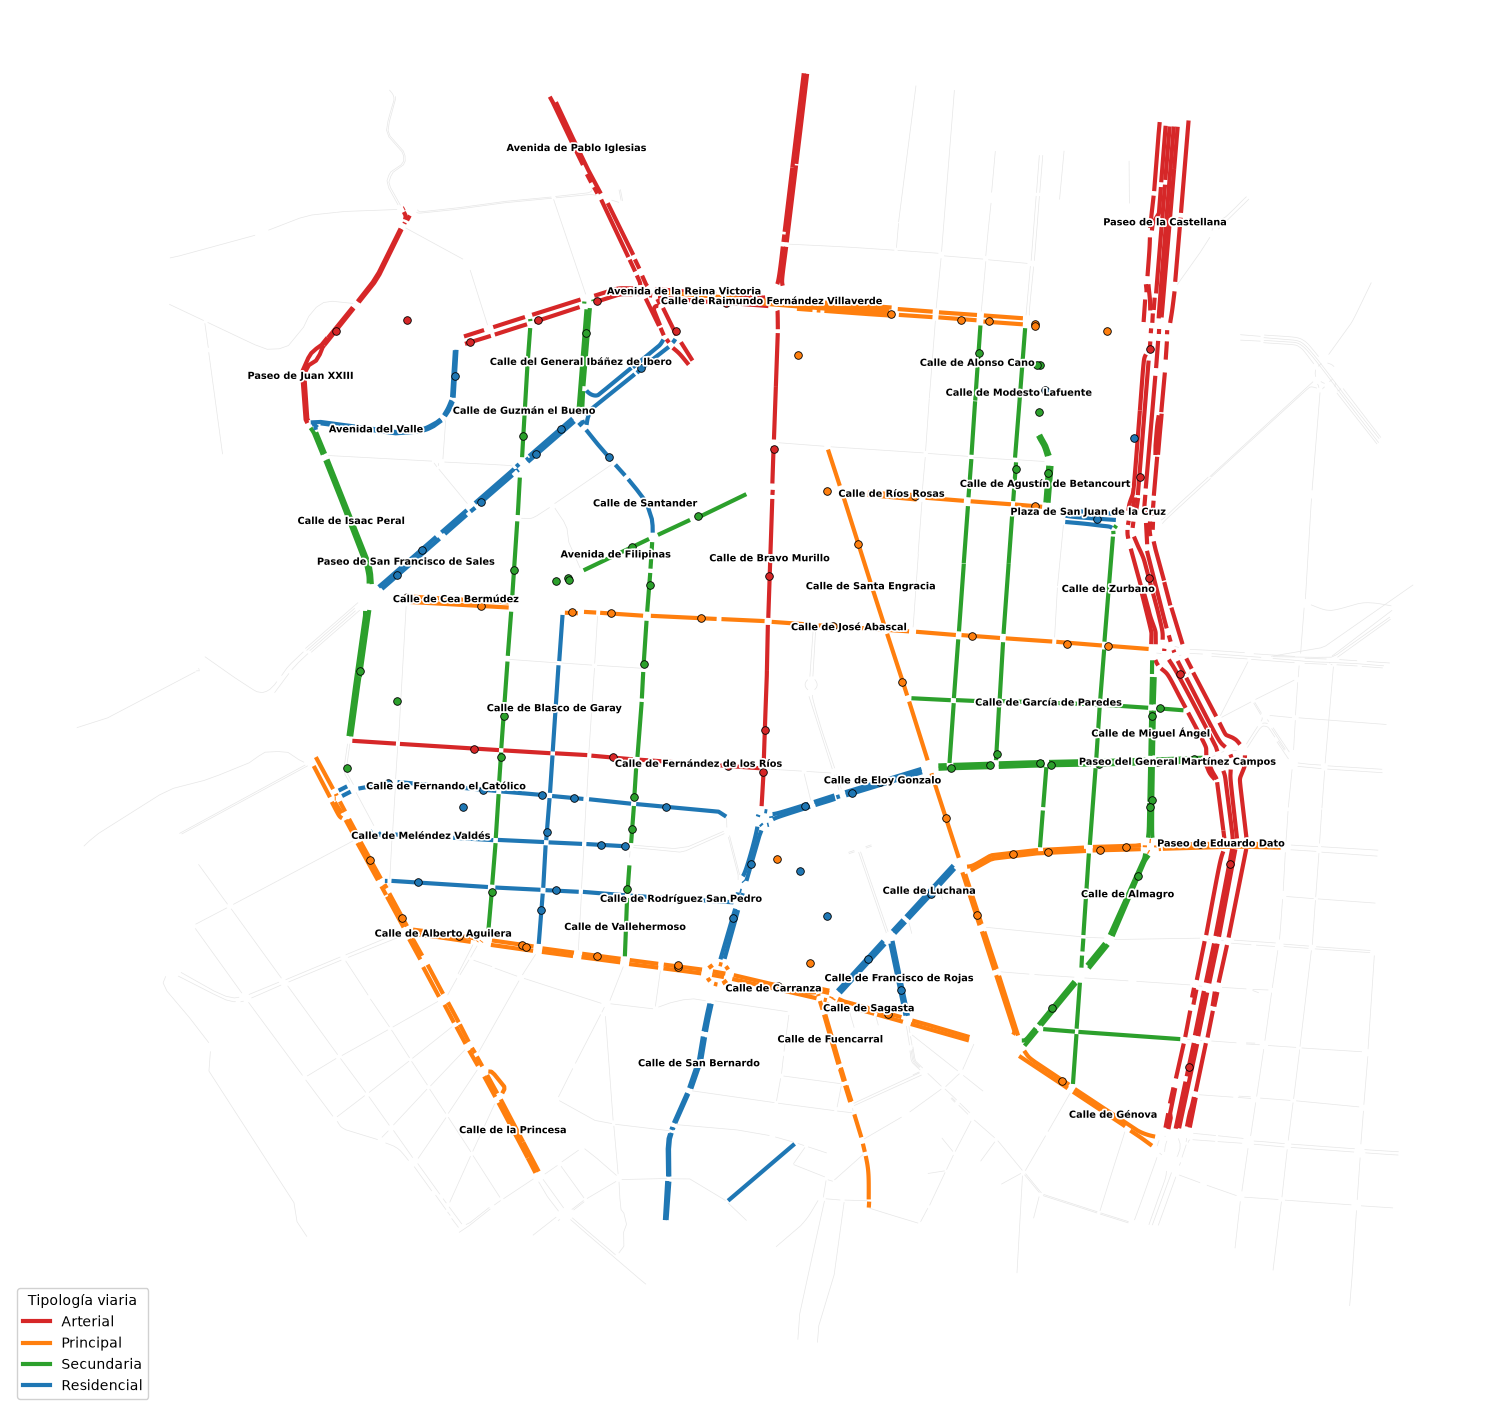

In [14]:
DIR_CARRILES = Path(r'C:\Users\ElsaBlacoArmengod\OneDrive - Educa Bidco\Escritorio\personal\TFM\numero_carriles_calle')
grafo = gpd.read_file(glob.glob(str(DIR_CARRILES / '*.shp'))[0]).dropna(subset=['Calle'])

# Normalización común para los nombres del grafo y las claves del diccionario
PALABRAS_VACIAS = r'\b(calle|avenida|avda|av|paseo|pza|plaza|pl|glorieta|ronda|travesia|de|del|la|las|los|el|y)\b'

def norm_nombre(s):
    s = quita_tildes(str(s).lower()).replace('pº', ' ')
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    s = re.sub(PALABRAS_VACIAS, ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

# Claves del diccionario, de la más larga a la más corta (las salidas no son calles del grafo)
CLAVES_GRAFO = sorted({(norm_nombre(c), t, ALIAS_VIA.get(c, c))
                       for t, cs in CLASIF.items() for c in cs if c != 'salida'},
                      key=lambda x: -len(x[0]))

def tipologia_calle(nombre):
    n = norm_nombre(nombre)
    for clave, tipo, canon in CLAVES_GRAFO:
        if re.search(rf'\b{re.escape(clave)}\b', n):
            return tipo, canon
    return None, None

# Se clasifica cada nombre de calle una sola vez
nombres = pd.Series(grafo['Calle'].unique())
clasif_calles = pd.DataFrame(nombres.apply(tipologia_calle).tolist(), index=nombres, columns=['tipologia', 'via_clave'])
grafo = grafo.join(clasif_calles, on='Calle')

# Sensores y zona del mapa
d_graf = df_id.dropna(subset=['longitud', 'latitud']).copy()
gs = gpd.GeoDataFrame(d_graf, geometry=[Point(xy) for xy in zip(d_graf['longitud'], d_graf['latitud'])],
                      crs='EPSG:4326').to_crs(grafo.crs)
minx, miny, maxx, maxy = gs.total_bounds
mg = 400
zona = grafo.cx[minx - mg:maxx + mg, miny - mg:maxy + mg].copy()

# Sensores cuya vía no aparece en el grafo, se representan con un punto
vias_en_grafo = set(zona['via_clave'].dropna())
solo_punto = d_graf[~d_graf['via_clave'].isin(vias_en_grafo)]
print(f'Sensores cuya vía no se encuentra en el grafo de carriles: {len(solo_punto)}')
if not solo_punto.empty:
    print(solo_punto[['id', 'nombre', 'via_clave', 'tipologia']].to_string(index=False))

# Mapa
fig, ax = plt.subplots(figsize=(15, 15))
zona[zona['tipologia'].isna()].plot(ax=ax, color='#e6e6e6', linewidth=0.5, zorder=1)
for tipo in ORDEN_TIP:
    sub = zona[zona['tipologia'] == tipo]
    if not sub.empty:
        sub.plot(ax=ax, color=COLORES_TIP[tipo], linewidth=3, zorder=3)
    sub = gs[gs['tipologia'] == tipo]
    if not sub.empty:
        sub.plot(ax=ax, color=COLORES_TIP[tipo], markersize=30, edgecolor='black', linewidth=0.6, zorder=5)

# Un nombre por vía, en su tramo más largo
clasificadas = zona[zona['tipologia'].notna()].copy()
clasificadas['long_tramo'] = clasificadas.geometry.length
etiquetas = clasificadas.loc[clasificadas.groupby('via_clave')['long_tramo'].idxmax()]
for _, row in etiquetas.iterrows():
    pt = row.geometry.interpolate(0.5, normalized=True)
    nombre = NOMBRE_OFICIAL.get(row['via_clave'], row['Calle'].title())
    ax.annotate(nombre, (pt.x, pt.y), fontsize=7, fontweight='bold', ha='center', va='center', zorder=6,
                path_effects=[withStroke(linewidth=2.5, foreground='white')])

ax.set_axis_off()
ax.legend(handles=[Line2D([0], [0], color=COLORES_TIP[t], linewidth=3, label=t) for t in ORDEN_TIP],
          title='Tipología viaria', loc='lower left', framealpha=0.9)
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'mapa_tipologia_original_nombres.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Selección de la batería de sensores

El objetivo no es modelar todos los tramos de la red, sino disponer de una muestra que reproduzca los distintos comportamientos del tráfico del distrito y permita comparar el efecto de los escenarios entre tipologías. Muchos sensores registran patrones muy similares al ubicarse en vías equivalentes, por lo que incluirlos todos aportaría información redundante.

El procedimiento consta de cinco pasos:

1. Filtro de calidad: completitud ≥ 0,98.
2. Comprobación de que DCL e ICPM no son redundantes.
3. Métrica compuesta: combinación lineal de DCL e ICPM normalizados (min–max).
4. Elección del peso de la métrica mediante un análisis de estabilidad de la selección.
5. Selección final: los tres sensores de mayor métrica en cada tipología, sin repetir vía.

### Filtro de completitud

In [15]:
aptos = df_indicadores[(df_indicadores['Completitud'] >= COMPLETITUD_MIN)
                       & df_indicadores['DCL'].notna()
                       & df_indicadores['ICPM'].notna()].copy()

print(f'Sensores aptos (completitud ≥ {COMPLETITUD_MIN:.2f}): {len(aptos)} de {len(df_indicadores)} '
      f'({100 * len(aptos) / len(df_indicadores):.1f} %)')
print('\nAptos por tipología:')
print(aptos['tipologia'].value_counts().reindex(ORDEN_TIP).to_string())

Sensores aptos (completitud ≥ 0.98): 94 de 134 (70.1 %)

Aptos por tipología:
tipologia
Arterial       15
Principal      31
Secundaria     24
Residencial    24


### Correlación entre DCL e ICPM

Se comprueba que los dos indicadores aportan información distinta antes de combinarlos.

In [16]:
r_p, p_p = pearsonr(aptos['DCL'], aptos['ICPM'])
r_s, p_s = spearmanr(aptos['DCL'], aptos['ICPM'])
print(f'Sensores aptos (n = {len(aptos)})')
print(f'  Pearson  r = {r_p:.3f}  (p = {p_p:.4f})   r² = {r_p ** 2:.2f}')
print(f'  Spearman ρ = {r_s:.3f}  (p = {p_s:.4f})')

Sensores aptos (n = 94)
  Pearson  r = 0.593  (p = 0.0000)   r² = 0.35
  Spearman ρ = 0.579  (p = 0.0000)


La correlación es moderada y significativa (r ≈ 0,59), lo que es esperable porque ambos indicadores comparten en el numerador la carga media de la franja punta laborable. Sin embargo, r² ≈ 0,35: solo un 35 % de la varianza de uno se explica por el otro. Los indicadores están relacionados pero no son redundantes, y tiene sentido emplear ambos.

### Métrica compuesta y función de selección

$$\text{Métrica} = w \cdot DCL_{norm} + (1 - w) \cdot ICPM_{norm}$$

La normalización min–max se calcula sobre los sensores aptos.

In [17]:
for col in ['DCL', 'ICPM']:
    mn, mx = aptos[col].min(), aptos[col].max()
    aptos[f'{col}_norm'] = (aptos[col] - mn) / (mx - mn) if mx > mn else 0.0


def seleccionar_sensores(candidatos: pd.DataFrame, peso_dcl: float, cuotas: dict = CUOTAS,
                         col_tip: str = 'tipologia', col_via: str = 'via_clave') -> pd.DataFrame:
    d = candidatos.copy()
    d['score'] = peso_dcl * d['DCL_norm'] + (1 - peso_dcl) * d['ICPM_norm']
    d['Metrica_compuesta'] = d['score'].round(3)
    d = d.sort_values('score', ascending=False, kind='mergesort')

    elegidos, vias_ocupadas = [], set()          
    for tipo, cuota in cuotas.items():
        n = 0
        for _, r in d[d[col_tip] == tipo].iterrows():
            if n >= cuota:
                break
            if r[col_via] in vias_ocupadas:
                continue
            elegidos.append(r['id'])
            vias_ocupadas.add(r[col_via])
            n += 1
    return d[d['id'].isin(elegidos)].drop(columns='score').reset_index(drop=True)

### Análisis de estabilidad de la selección frente al peso

Se recalcula la selección para cada peso de DCL entre 0,20 y 0,80 (paso 0,05) y se compara cada configuración con la contigua. El peso se elige dentro del intervalo en el que la selección permanece invariante.

In [18]:
sel_por_peso = {w: set(seleccionar_sensores(aptos, w)['id']) for w in PESOS_ESTABILIDAD}
n_sel = sum(CUOTAS.values())

estabilidad = pd.DataFrame([
    {'peso_DCL_1': a, 'peso_DCL_2': b,
     'comunes': len(sel_por_peso[a] & sel_por_peso[b]),
     'cambian': len(sel_por_peso[a] ^ sel_por_peso[b]) // 2}
    for a, b in zip(PESOS_ESTABILIDAD, PESOS_ESTABILIDAD[1:])])
estabilidad.to_csv(CARPETA_SALIDA / 'estabilidad_seleccion_pesos.csv', index=False)
print(f'Estabilidad de la selección entre pesos contiguos (sobre {n_sel} sensores)\n')
print(estabilidad.to_string(index=False))

# Intervalos de pesos consecutivos con la misma selección
intervalos, inicio = [], PESOS_ESTABILIDAD[0]
for a, b in zip(PESOS_ESTABILIDAD, PESOS_ESTABILIDAD[1:]):
    if sel_por_peso[a] != sel_por_peso[b]:
        intervalos.append((inicio, a))
        inicio = b
intervalos.append((inicio, PESOS_ESTABILIDAD[-1]))
print('\nIntervalos de pesos con selección invariante:')
for ini, fin in intervalos:
    print(f'  [{ini:.2f}, {fin:.2f}]')

Estabilidad de la selección entre pesos contiguos (sobre 12 sensores)

 peso_DCL_1  peso_DCL_2  comunes  cambian
       0.20        0.25       12        0
       0.25        0.30       11        1
       0.30        0.35       12        0
       0.35        0.40       12        0
       0.40        0.45       12        0
       0.45        0.50       11        1
       0.50        0.55       12        0
       0.55        0.60       12        0
       0.60        0.65       11        1
       0.65        0.70       12        0
       0.70        0.75       10        2
       0.75        0.80       11        1

Intervalos de pesos con selección invariante:
  [0.20, 0.25]
  [0.30, 0.45]
  [0.50, 0.60]
  [0.65, 0.70]
  [0.75, 0.75]
  [0.80, 0.80]


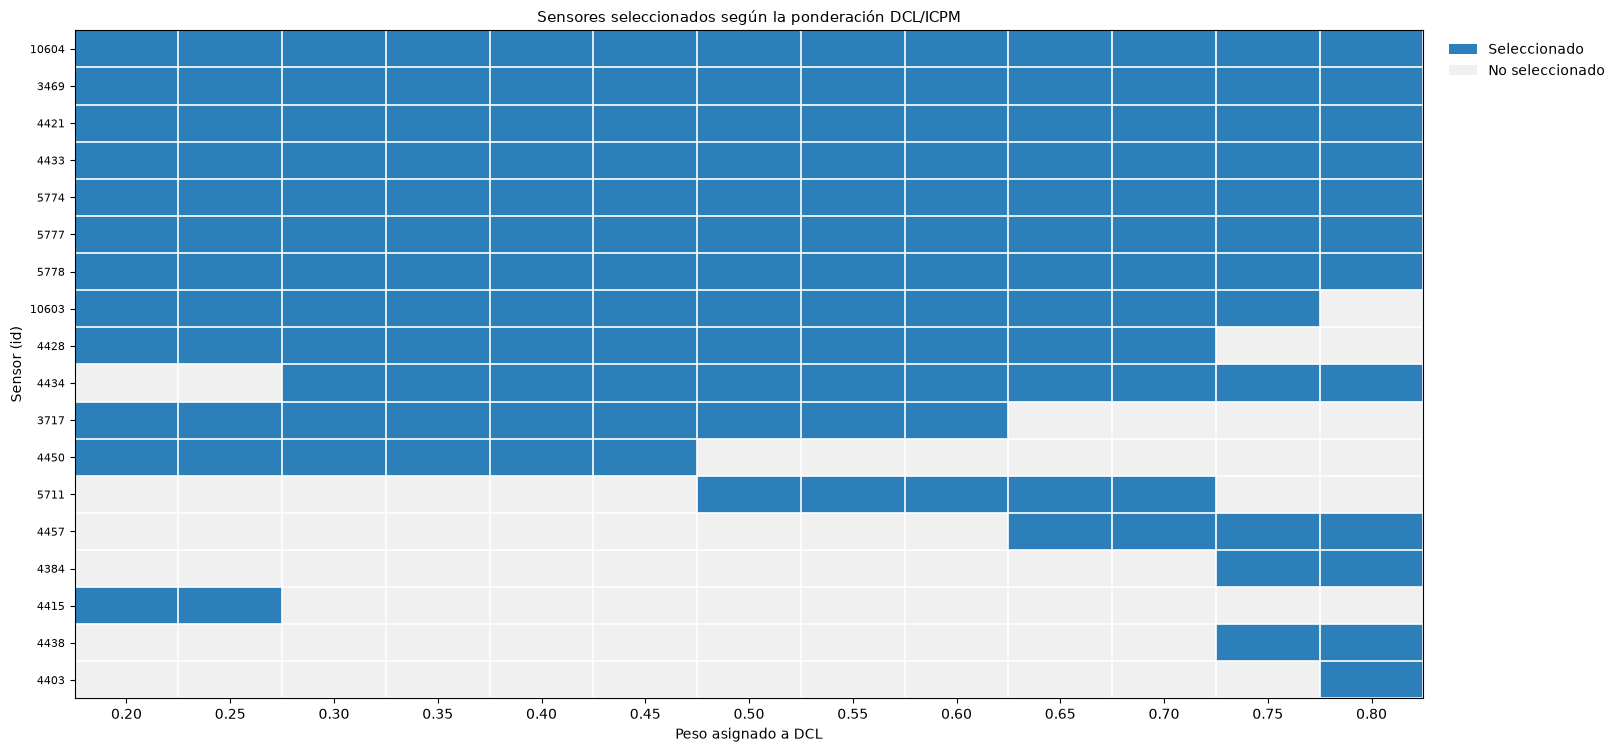

In [19]:
ids_estab = sorted(set().union(*sel_por_peso.values()),
                   key=lambda s: (-sum(s in sel_por_peso[w] for w in PESOS_ESTABILIDAD), s))
M = np.array([[1 if sid in sel_por_peso[w] else 0 for w in PESOS_ESTABILIDAD] for sid in ids_estab])

fig, ax = plt.subplots(figsize=(1.1 * len(PESOS_ESTABILIDAD) + 2, 0.34 * len(ids_estab) + 1.5))
ax.imshow(M, aspect='auto', cmap=ListedColormap(['#f0f0f0', '#2c7fb8']), vmin=0, vmax=1)
ax.set_xticks(range(len(PESOS_ESTABILIDAD)))
ax.set_xticklabels([f'{w:.2f}' for w in PESOS_ESTABILIDAD])
ax.set_xlabel('Peso asignado a DCL')
ax.set_yticks(range(len(ids_estab)))
ax.set_yticklabels(ids_estab, fontsize=8)
ax.set_ylabel('Sensor (id)')
ax.set_title('Sensores seleccionados según la ponderación DCL/ICPM', fontsize=11)
ax.set_xticks(np.arange(-.5, len(PESOS_ESTABILIDAD), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(ids_estab), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.2)
ax.tick_params(which='minor', length=0)
ax.legend(handles=[Patch(facecolor='#2c7fb8', label='Seleccionado'),
                   Patch(facecolor='#f0f0f0', label='No seleccionado')],
          loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)
plt.tight_layout()
plt.savefig(CARPETA_SALIDA / 'estabilidad_seleccion_pesos.png', dpi=300, bbox_inches='tight')
plt.show()

Entre 0,50 y 0,70 la selección solo presenta dos 
configuraciones que coinciden en los intervalos 0,50–0,60 y 0,65–0,70. Ambas se 
diferencian en un único sensor de tipología secundaria: el 3717 en la primera y el 4457 
en la segunda. Se comprueba cuál tiene mayor DCL.

In [20]:
cols = ['id', 'nombre_via', 'tipologia', 'carga_punta_lab', 'carga_punta_nolab', 'carga_dia_lab', 'DCL', 'ICPM', 'Completitud']
df_indicadores[df_indicadores['id'].isin(['3717', '4457'])][cols].round(3)

,id,nombre_via,tipologia,carga_punta_lab,carga_punta_nolab,carga_dia_lab,DCL,ICPM,Completitud
27,3717,ISAAC PERAL S-N (DONOSO CORTES-CEA BERMUDEZ),Secundaria,24.171,7.370,15.769,16.80,1.533,0.981
93,4457,"Modesto Lafuente, 40 N-S(Cristóbal Bordiu-Rios...",Secundaria,46.427,19.989,42.606,26.44,1.090,0.993


### Selección final

Se adopta un peso de **0,65 para DCL** (0,35 para ICPM), situado dentro de un intervalo de pesos en el que la selección permanece estable.


In [21]:
PESO_DCL  = 0.65
PESO_ICPM = round(1 - PESO_DCL, 2)

aptos['Metrica_compuesta'] = (PESO_DCL * aptos['DCL_norm'] + PESO_ICPM * aptos['ICPM_norm']).round(3)
seleccion = (seleccionar_sensores(aptos, PESO_DCL)
             .sort_values('Metrica_compuesta', ascending=False).reset_index(drop=True))
seleccion.index += 1

print(f'Vías repetidas en la selección: {seleccion["via_clave"].duplicated().sum()}')
print(f'Sensores por tipología: {seleccion["tipologia"].value_counts().reindex(ORDEN_TIP).to_dict()}\n')
cols_out = ['id', 'nombre_via', 'tipologia', 'DCL', 'ICPM', 'Completitud', 'Metrica_compuesta']
print(seleccion[cols_out].to_string())

aptos.sort_values('Metrica_compuesta', ascending=False).to_csv(
    CARPETA_SALIDA / 'ranking_sensores_chamberi.csv', index=False)
seleccion.to_csv(CARPETA_SALIDA / 'sensores_seleccionados_chamberi.csv', index=True)

Vías repetidas en la selección: 0
Sensores por tipología: {'Arterial': 3, 'Principal': 3, 'Secundaria': 3, 'Residencial': 3}

       id                                                     nombre_via    tipologia    DCL    ICPM  Completitud  Metrica_compuesta
1    4421                Cea Bermúdez, 4 O-E(Boix y Morer-Bravo Murillo)    Principal  39.31  1.5136        0.996              0.911
2    5774                        Av.Moncloa O-E  - La Granja - Del Valle     Arterial  33.51  1.7416        0.990              0.896
3    5777  Av. Reina Victoria O-E  - Gral. Ibáñez Íbero - Pablo Iglesias     Arterial  33.81  1.6040        0.994              0.847
4    3469  SAN FRANCISCO DE SALES S-N (ANDRES MELLADO - GUZMAN EL BUENO)  Residencial  33.59  1.6038        0.991              0.843
5   10604    Blasco de Garay S-N (Alberto Aguilera -Rodríguez San Pedro)  Residencial  33.75  1.5538        0.996              0.827
6    4428         Gral. Martinez Campos, 24 O-E(Fdez. de la Hoz-Zurbano)   S

### Caracterización de los 12 sensores seleccionados

In [22]:
tabla_tipologias_12 = caracterizar_tipologias(seleccion, titulo='Caracterización de los 12 sensores seleccionados')
tabla_tipologias_12.to_csv(CARPETA_SALIDA / 'caracterizacion_tipologias_12.csv')
tabla_tipologias_12

Caracterización de los 12 sensores seleccionados


,n_sensores,carga_punta_lab,carga_punta_nolab,carga_dia_lab,DCL_media,ICPM_medio
tipologia,,,,,,
Arterial,3,35.63,6.31,22.18,29.33,1.60
Principal,3,47.19,12.47,31.97,34.72,1.47
Secundaria,3,37.40,9.96,28.04,27.43,1.44
Residencial,3,42.76,11.34,27.94,31.42,1.52


### Distribución espacial de los sensores seleccionados

Distrito(s) de los sensores seleccionados: [7] (esperado: [7])


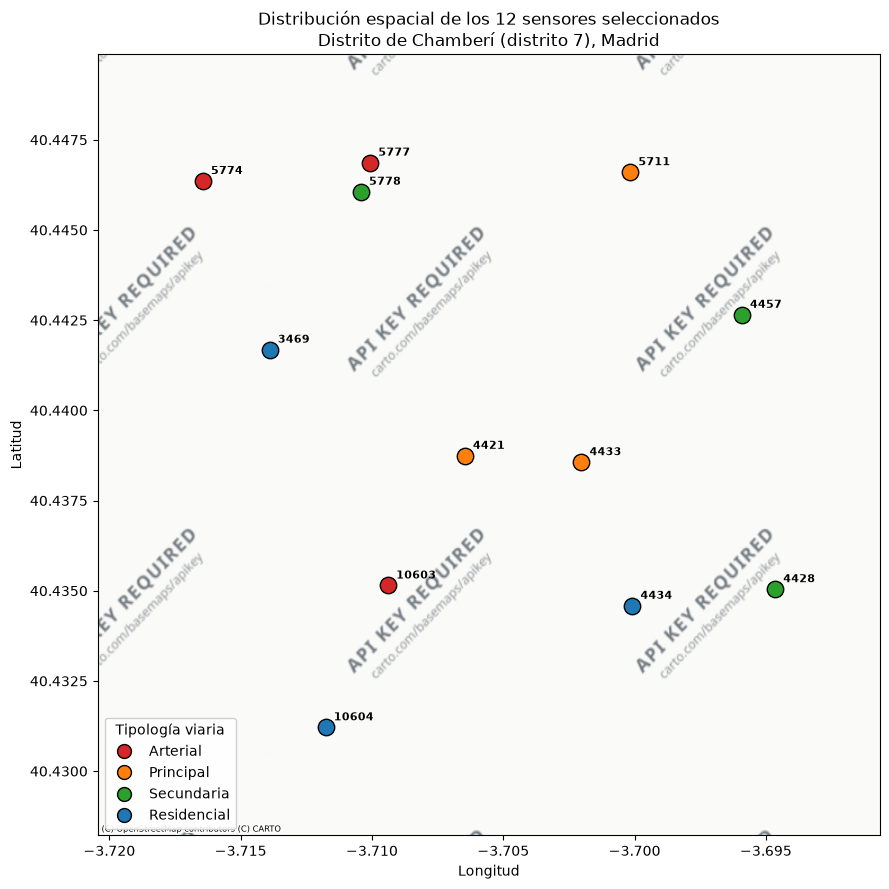

In [23]:
df_mapa = seleccion.merge(df_id[['id', 'distrito', 'longitud', 'latitud']], on='id', how='left')
print(f'Distrito(s) de los sensores seleccionados: {df_mapa["distrito"].dropna().astype(int).unique()} (esperado: [7])')

fig, ax = plt.subplots(figsize=(9, 9))
for tipo in ORDEN_TIP:
    sub = df_mapa[df_mapa['tipologia'] == tipo]
    if sub.empty:
        continue
    ax.scatter(sub['longitud'], sub['latitud'], c=COLORES_TIP[tipo], s=140,
               edgecolors='black', linewidths=1.0, zorder=5, label=tipo)
    for _, r in sub.iterrows():
        ax.annotate(r['id'], (r['longitud'], r['latitud']), xytext=(6, 5),
                    textcoords='offset points', fontsize=8, fontweight='bold', zorder=6)

try:
    import contextily as cx
    ax.set_xlim(df_mapa['longitud'].min() - 0.004, df_mapa['longitud'].max() + 0.004)
    ax.set_ylim(df_mapa['latitud'].min() - 0.003, df_mapa['latitud'].max() + 0.003)
    cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Positron, attribution_size=6)
except Exception as e:
    print(f'(Sin mapa de fondo: {e})')
    ax.grid(linestyle=':', alpha=0.4)
    ax.set_aspect('equal', adjustable='datalim')

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribución espacial de los 12 sensores seleccionados\nDistrito de Chamberí (distrito 7), Madrid', fontsize=12)
ax.legend(handles=[Line2D([0], [0], marker='o', linestyle='', markersize=10,
                          markerfacecolor=COLORES_TIP[t], markeredgecolor='black', label=t) for t in ORDEN_TIP],
          title='Tipología viaria', loc='lower left', framealpha=0.9)
fig.tight_layout()
fig.savefig(CARPETA_SALIDA / 'mapa_sensores_chamberi.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Apéndice. Selección sensores sin cuotas por tipología 

Los análisis de este apéndice se conservan como comprobaciones y como apoyo a la justificación metodológica de la memoria. 

In [24]:
def seleccionar_sin_cuotas(candidatos: pd.DataFrame, n: int) -> pd.DataFrame:
    elegidos, vias = [], set()
    for _, r in candidatos.sort_values('Metrica_compuesta', ascending=False).iterrows():
        if len(elegidos) >= n:
            break
        if r['via_clave'] in vias:
            continue
        elegidos.append(r['id'])
        vias.add(r['via_clave'])
    return candidatos[candidatos['id'].isin(elegidos)].sort_values('Metrica_compuesta', ascending=False)


sel_sin_cuotas = seleccionar_sin_cuotas(aptos, len(seleccion))
ids_final, ids_alt = set(seleccion['id']), set(sel_sin_cuotas['id'])
info = aptos.set_index('id')[['nombre_via', 'tipologia']]

print(f'Coinciden con la selección final: {len(ids_final & ids_alt)}/{len(ids_final)}')
print('\nSalen respecto a la selección final:')
for i in sorted(ids_final - ids_alt):
    print(f"  {i:>6}  [{info.loc[i, 'tipologia']:<11}]  {info.loc[i, 'nombre_via']}")
print('Entran:')
for i in sorted(ids_alt - ids_final):
    print(f"  {i:>6}  [{info.loc[i, 'tipologia']:<11}]  {info.loc[i, 'nombre_via']}")

print('\nReparto por tipología sin cuotas:', sel_sin_cuotas['tipologia'].value_counts().reindex(ORDEN_TIP).fillna(0).astype(int).to_dict())
print(sel_sin_cuotas[['id', 'nombre_via', 'tipologia', 'DCL', 'ICPM', 'Metrica_compuesta']].round(3).to_string(index=False))

Coinciden con la selección final: 10/12

Salen respecto a la selección final:
   10603  [Arterial   ]  Fernández de los Rios O-E(Galileo-Vallehermoso)
    4457  [Secundaria ]  Modesto Lafuente, 40 N-S(Cristóbal Bordiu-Rios Rosas)
Entran:
    4384  [Principal  ]  Alberto Aguilera, 44 E-O(Blasco de Gara-Guzmán el Bueno)
    4450  [Principal  ]  Eduardo Dato, 4 O-E(Fernández de la Hoz-Zurbano)

Reparto por tipología sin cuotas: {'Arterial': 2, 'Principal': 5, 'Secundaria': 2, 'Residencial': 3}
   id                                                    nombre_via   tipologia   DCL  ICPM  Metrica_compuesta
 4421               Cea Bermúdez, 4 O-E(Boix y Morer-Bravo Murillo)   Principal 39.31 1.514              0.911
 5774                       Av.Moncloa O-E  - La Granja - Del Valle    Arterial 33.51 1.742              0.896
 5777 Av. Reina Victoria O-E  - Gral. Ibáñez Íbero - Pablo Iglesias    Arterial 33.81 1.604              0.847
 3469 SAN FRANCISCO DE SALES S-N (ANDRES MELLADO - GUZMAN EL